In [1]:
import sys,os,re
import numpy             as np
import matplotlib.pyplot as plt
import pandas            as pd
import seaborn           as sb

from IPython.display import display

from source_code.fisher import get_Fisher

from getdist.gaussian_mixtures import GaussianND
from copy import deepcopy
from getdist import plots,loadMCSamples,MCSamples

import matplotlib
from matplotlib import rc
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}

# Settings

In [2]:
LSS_info = {'obs_settings': {'extra': None,
                             'case': 'simple',
                             'camb_path': '/home/Matteo/Codes/GW-MGCAMB',
                             'calculation': 'CAMB'},
            'analysis_settings': {'dist_path': './mock_data/LCDM_test_gal_source_distribution.npy',
                                  'lmin': 10,
                                  'lmax': 1500,
                                  'Nbin_ell': 20,
                                  'galaxy_specs': {'fsky': 0.35,
                                                   'gal_per_arcmin': 30.,
                                                   'sigma_eps': 0.3}},
            'sampler': {'Fisher': {'derivative': '2PT',#'polynomial',
                                   'freepars': {'ombh2': {'fiducial': 0.022445,
                                                          'variation': 0.1,
                                                          'latex': '\Omega_{\rm b}\,h^2'},
                                                'omch2': {'fiducial': 0.1205579307,
                                                          'variation': 0.1,
                                                          'latex': '\Omega_{\rm b}\,h^2'},
                                                'H0': {'fiducial': 67.,
                                                       'variation': 0.1,
                                                       'latex': 'H_0'},
                                                'ns': {'fiducial': 0.96,
                                                       'variation': 0.1,
                                                       'latex': 'n_{\rm s}'},
                                                'logA': {'fiducial': 3.05685,
                                                         'variation': 0.1,
                                                         'latex': '\log{10^{10}\,A_{\rm s}}'},
                                                'a0': {'fiducial': -0.007589,
                                                       'variation': 0.1,
                                                       'latex': 'a_0'},
                                                'a1': {'fiducial': 0.002008,
                                                       'variation': 0.1,
                                                       'latex': 'a_1'},
                                                'a2': {'fiducial': -0.004127,
                                                       'variation': 0.1,
                                                       'latex': 'a_2'},
                                                'a3': {'fiducial': 0.002918,
                                                       'variation': 0.1,
                                                       'latex': 'a_3'}, 
                                                'a4':{'fiducial': -0.0006784,
                                                      'variation': 0.1,
                                                      'latex': 'a_4'},
                                                'b0_poly': {'fiducial': 0.830703,
                                                            'variation': 0.1,
                                                            'latex': 'b_0'},
                                                'b1_poly': {'fiducial': 1.190547,
                                                            'variation': 0.1,
                                                            'latex': 'b_1'},
                                                'b2_poly': {'fiducial': -0.928357,
                                                            'variation': 0.1,
                                                            'latex': 'b_2'},
                                                'b3_poly': {'fiducial': 0.423292,
                                                            'variation': 0.1,
                                                            'latex': 'b_3'},
                                                'b0_poly_GW': {'fiducial': 0.830703,
                                                               'variation': 0.1,
                                                               'latex': 'b_0'},
                                                'b1_poly_GW': {'fiducial': 1.190547,
                                                               'variation': 0.1,
                                                               'latex': 'b_1'},
                                                'b2_poly_GW': {'fiducial': -0.928357,
                                                               'variation': 0.1,
                                                               'latex': 'b_2'},
                                                'b3_poly_GW': {'fiducial': 0.423292,
                                                               'variation': 0.1,
                                                               'latex': 'b_3'}},
                                   'fixedpars': {'tau': 0.05,
                                                 'w': -1.,
                                                 'wa': 0.,
                                                 'mnu': 0.06}}}}

In [3]:
info_vec = {'3x2pt': deepcopy(LSS_info)}

gwinfo = deepcopy(LSS_info)
gwinfo['analysis_settings']['dist_path'] = './mock_data/MGflag_1_test_galGWs_Nbin6_source_distribution.npy'
gwinfo['analysis_settings']['GW_specs'] = {'N_gw': int(1.e6),
                                           'sigma_eps_gw': 0.01,
                                           'fsky': 0.35,
                                           'theta_min': 0.}



info_vec[r'3x2pt+GW ($\theta_{\rm min} = 0$)'] = gwinfo

gwinfo = deepcopy(LSS_info)
gwinfo['analysis_settings']['dist_path'] = './mock_data/MGflag_1_test_galGWs_Nbin6_source_distribution.npy'
gwinfo['analysis_settings']['GW_specs'] = {'N_gw': int(1.e6),
                                           'sigma_eps_gw': 0.01,
                                           'fsky': 0.35,
                                           'theta_min': 0.01}



info_vec[r'3x2pt+GW ($\theta_{\rm min} = 0.01$)'] = gwinfo

In [4]:
create_mock_data = r'3x2pt+GW ($\theta_{\rm min} = 0.01$)'

# Running the Fisher matrix pipeline

## Initialize Fisher class and get fiducial observables

In [5]:
fidvec = []
for name,info in info_vec.items():
    print('')
    print(name)
    
    lmin = np.log10(info['analysis_settings']['lmin'])
    lmax = np.log10(info['analysis_settings']['lmax'])
    N    = info['analysis_settings']['Nbin_ell']

    obs_settings = info['obs_settings']

    if obs_settings['extra'] == None:
        obs_settings['extra'] = {}

    ell_lims = np.logspace(lmin,lmax,N) #creation of array-> N bin log spaced
    ells     = np.array([int(ell) for ell in 0.5*(ell_lims[:-1]+ell_lims[1:])])
    deltas   = (ell_lims[1:]-ell_lims[:-1]) #evaluation of the amplitude of each bin

    distributions = np.load(info['analysis_settings']['dist_path'],allow_pickle=True).item()

    galaxy_specs  = info['analysis_settings']['galaxy_specs']

    free_params = info['sampler']['Fisher']['freepars']
    
    #MMmod: to be changed to work only with GW only?#####
    if 'GWWL' in distributions or 'GWC' in distributions:
        GW_specs = info['analysis_settings']['GW_specs']
    else:
        for i in range(4):
            info['sampler']['Fisher']['fixedpars']['b{}_poly_GW'.format(i)] = free_params['b{}_poly_GW'.format(i)]['fiducial']
            del free_params['b{}_poly_GW'.format(i)]
        GW_specs = {}
        
    

    fiducial = {par: pardict['fiducial'] for par,pardict in free_params.items()} | info['sampler']['Fisher']['fixedpars']
    dertype  = info['sampler']['Fisher']['derivative']
    
    fishmodule = get_Fisher(fiducial,free_params,ells,deltas,distributions,obs_settings,galaxy_specs,GW_specs,dertype)

    info['fishing_tools'] = fishmodule
    
    fiddf = fishmodule.fidobs
    fiddf['Case'] = name
    fidvec.append(fiddf)
    #fishmat    = fishmodule.fisher_matrix()

    #fisher = pd.DataFrame(fishmat,columns=free_params.keys(),index=free_params.keys())
    #params_info = {par: val for par,val in free_params.items()}

fiducial_obs = pd.concat(fidvec,ignore_index=True).fillna(0)


3x2pt

Computing fiducial observables...
...done in 156.01 s

3x2pt+GW ($\theta_{\rm min} = 0$)

Computing fiducial observables...
...done in 173.60 s

3x2pt+GW ($\theta_{\rm min} = 0.01$)

Computing fiducial observables...
...done in 163.83 s


### Plotting Fiducial

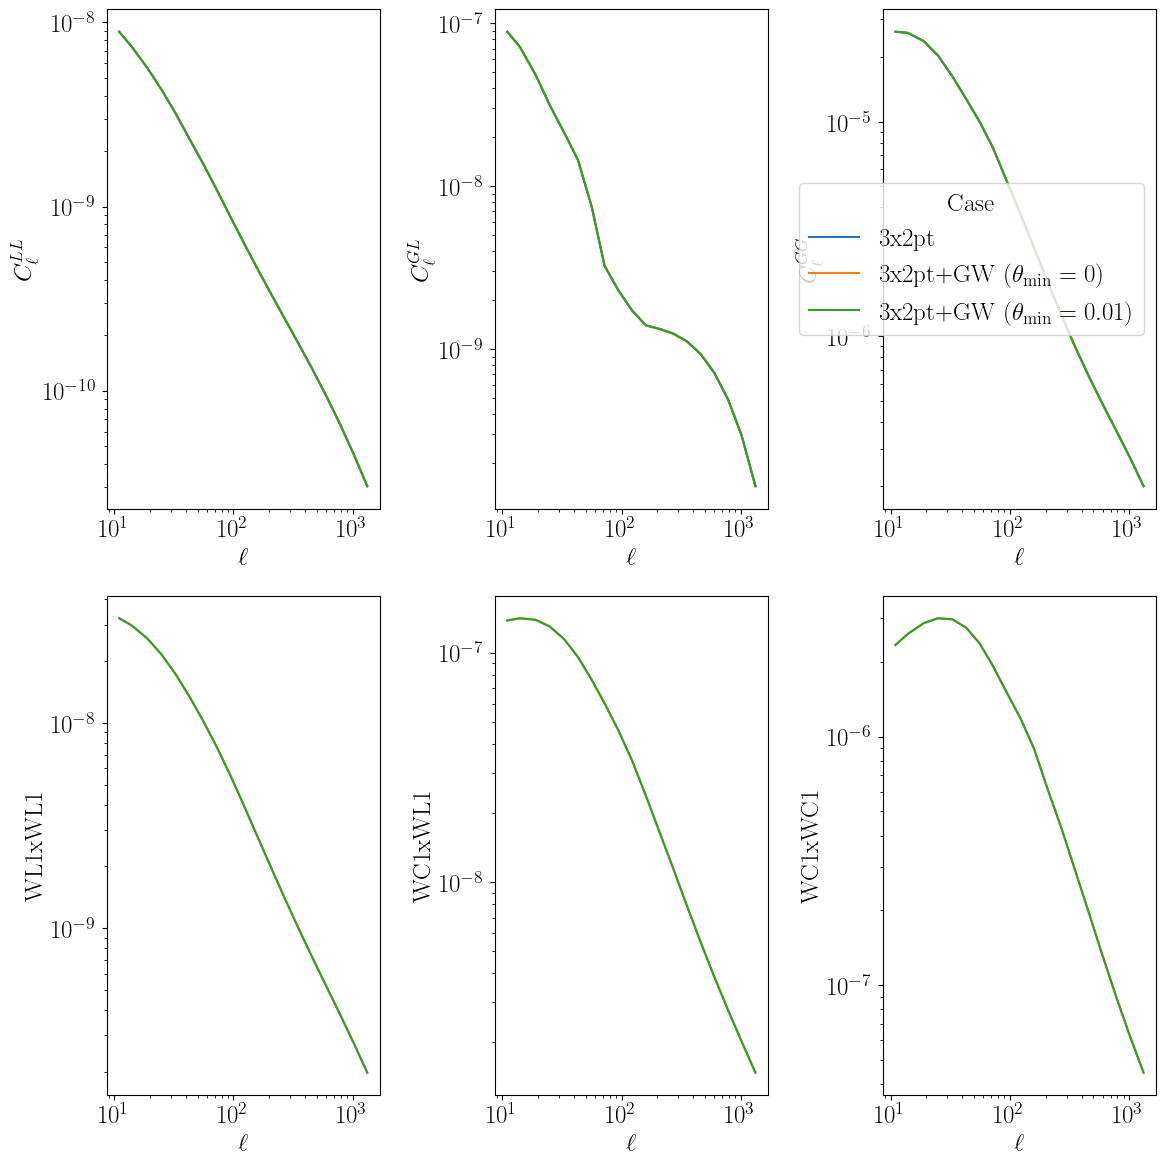

In [6]:
fig, ax = plt.subplots(2,3, figsize = (12,12))

sb.lineplot(fiducial_obs,x='ells',y='L1xL1',hue='Case',ax=ax[0,0],legend=0)
sb.lineplot(fiducial_obs,x='ells',y='G1xL1',hue='Case',ax=ax[0,1],legend=0)
sb.lineplot(fiducial_obs,x='ells',y='G1xG1',hue='Case',ax=ax[0,2])

sb.lineplot(fiducial_obs,x='ells',y='WL1xWL1',hue='Case',ax=ax[1,0],legend=0)
sb.lineplot(fiducial_obs,x='ells',y='WC1xWL1',hue='Case',ax=ax[1,1],legend=0)
sb.lineplot(fiducial_obs,x='ells',y='WC1xWC1',hue='Case',ax=ax[1,2],legend=0)

ax[0,0].set_ylabel(r'$C^{LL}_\ell$')
ax[0,1].set_ylabel(r'$C^{GL}_\ell$')
ax[0,2].set_ylabel(r'$C^{GG}_\ell$')
for ax in ax.reshape(-1): 
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$')
    
plt.tight_layout();

## Get noise

In [7]:
noisevec = []
for name,info in info_vec.items():

    noise = info['fishing_tools'].get_noise()
    noise['Case'] = name

    noisevec.append(noise)

noise_obs = pd.concat(noisevec,ignore_index=True).fillna(0)

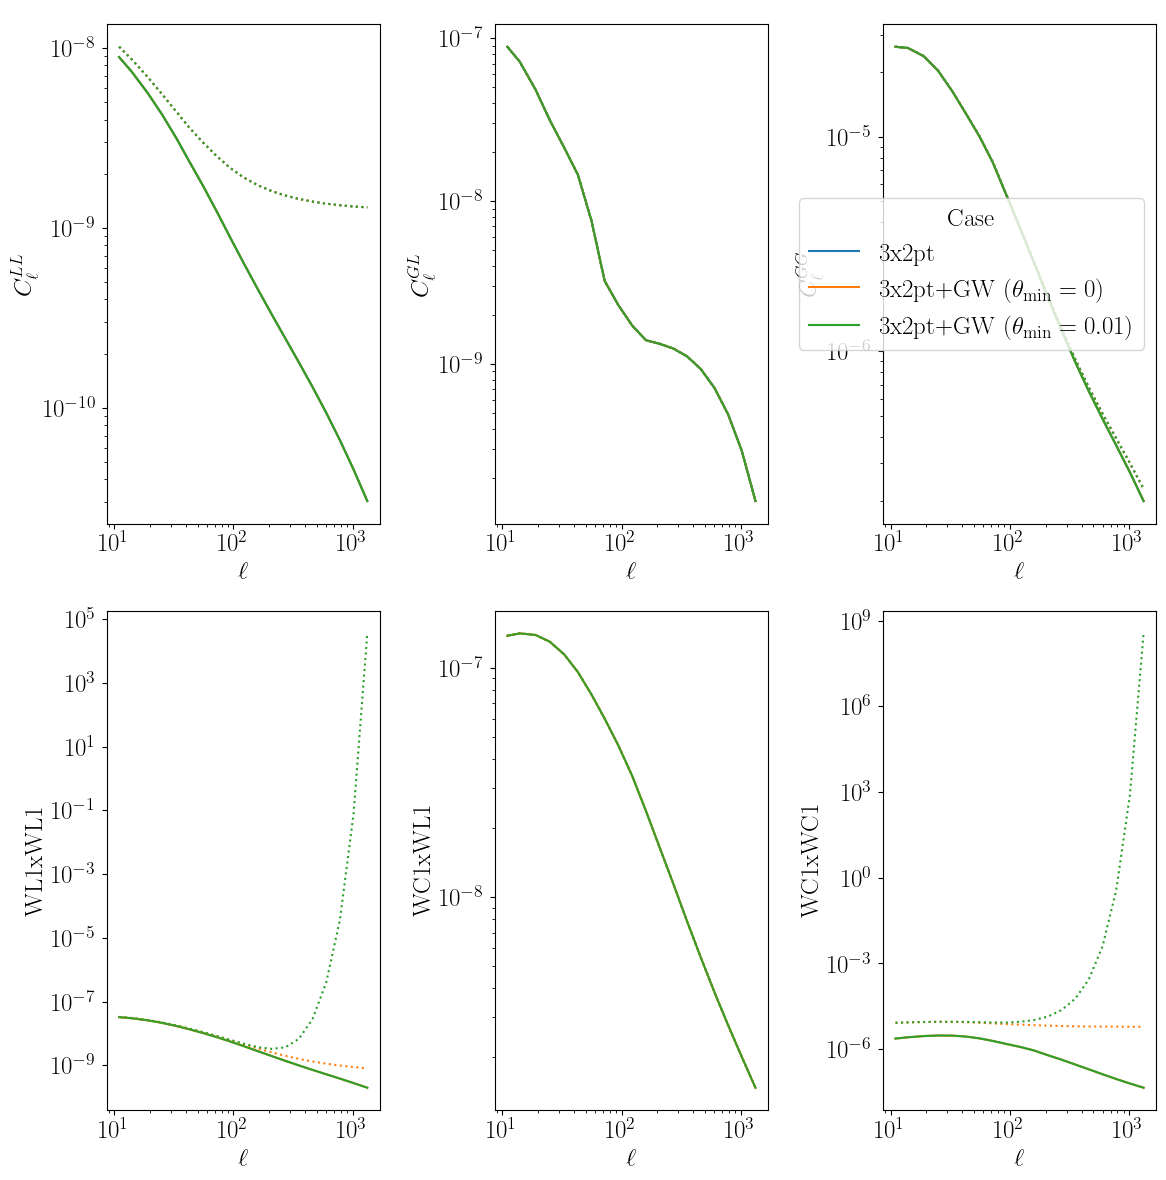

In [8]:
full_noise = pd.DataFrame({'ells': noise_obs['ells']})
for col in noise_obs.columns:
    if col != 'ells':
        full_noise[col] = [(fiducial_obs.at[ind,col]+noise_obs.at[ind,col]) for ind in full_noise.index]


fig, ax = plt.subplots(2,3, figsize = (12,12))


sb.lineplot(fiducial_obs,x='ells',y='L1xL1',hue='Case',ax=ax[0,0],legend=0)
sb.lineplot(fiducial_obs,x='ells',y='G1xL1',hue='Case',ax=ax[0,1],legend=0)
sb.lineplot(fiducial_obs,x='ells',y='G1xG1',hue='Case',ax=ax[0,2])

sb.lineplot(fiducial_obs,x='ells',y='WL1xWL1',hue='Case',ax=ax[1,0],legend=0)
sb.lineplot(fiducial_obs,x='ells',y='WC1xWL1',hue='Case',ax=ax[1,1],legend=0)
sb.lineplot(fiducial_obs,x='ells',y='WC1xWC1',hue='Case',ax=ax[1,2],legend=0)

sb.lineplot(full_noise,x='ells',y='L1xL1',hue='Case',ax=ax[0,0],legend=0,linestyle=':')
sb.lineplot(full_noise,x='ells',y='G1xL1',hue='Case',ax=ax[0,1],legend=0,linestyle=':')
sb.lineplot(full_noise,x='ells',y='G1xG1',hue='Case',ax=ax[0,2],legend=0,linestyle=':')

sb.lineplot(full_noise,x='ells',y='WL1xWL1',hue='Case',ax=ax[1,0],legend=0,linestyle=':')
sb.lineplot(full_noise,x='ells',y='WC1xWL1',hue='Case',ax=ax[1,1],legend=0,linestyle=':')
sb.lineplot(full_noise,x='ells',y='WC1xWC1',hue='Case',ax=ax[1,2],legend=0,linestyle=':')

ax[0,0].set_ylabel(r'$C^{LL}_\ell$')
ax[0,1].set_ylabel(r'$C^{GL}_\ell$')
ax[0,2].set_ylabel(r'$C^{GG}_\ell$')
for ax in ax.reshape(-1): 
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$')
    #ax.get_legend().remove()

#plt.legend(**sidelegend)
# add legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=3, bbox_to_anchor=(0.8, 1), frameon=False)


plt.tight_layout();

## Get covmat

In [9]:
for name,info in info_vec.items():

    covmat   = info['fishing_tools'].compute_covmat()
    all_cols = info['fishing_tools'].columns_ordering()
    
    info['covmats'] = []
    
    for ellind,ell in enumerate(info['fishing_tools'].fidobs['ells']):
        info['covmats'].append(info['fishing_tools'].pack_covmat(covmat,ellind,all_cols))

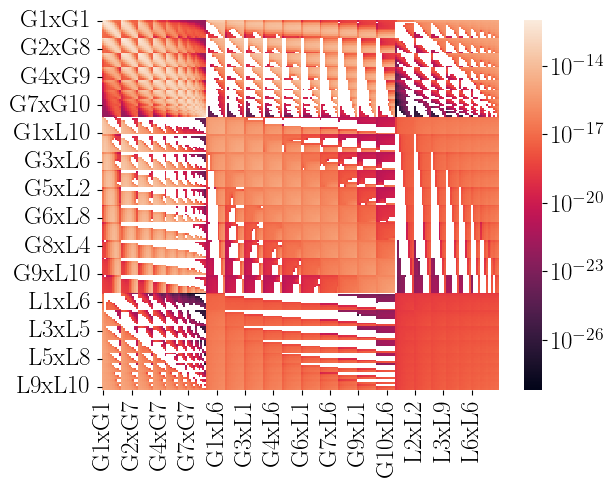

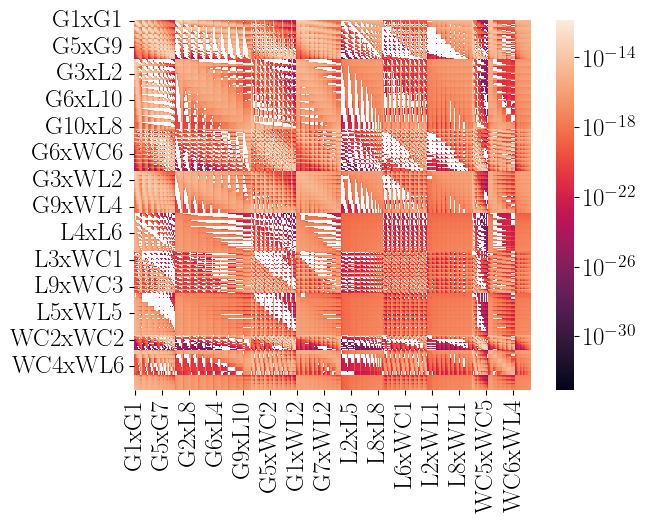

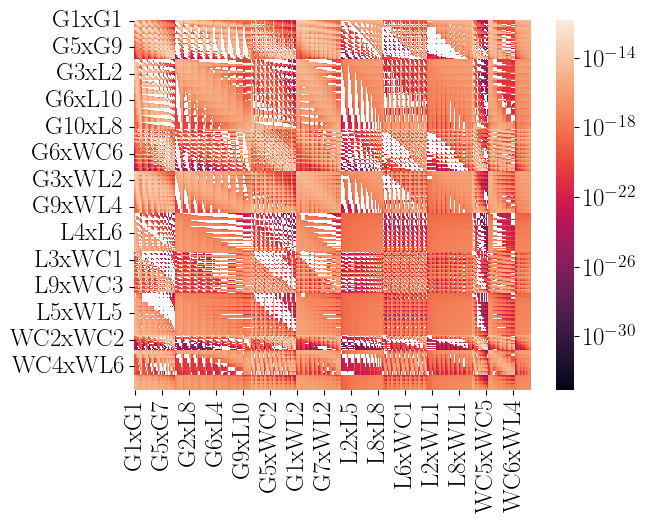

In [10]:
ellind_to_plot = 5

for name,info in info_vec.items():

    plt.figure()
    sb.heatmap(info['covmats'][ellind_to_plot],norm=LogNorm())

## Generate and store dataset (if requested)

In [11]:
if create_mock_data != '':
    loc_dict = deepcopy(info_vec[create_mock_data])
    theoryvec = loc_dict['fishing_tools'].fidobs
    cols = loc_dict['covmats'][0].columns
    datavec = pd.DataFrame(columns=cols,index=theoryvec.index,dtype='float')
    for ellind,ell in enumerate(theoryvec['ells']):
        datavec.iloc[ellind] = np.random.multivariate_normal(theoryvec[cols].iloc[ellind],loc_dict['covmats'][ellind])

## Get derivatives

## Get Fisher

In [12]:
stop = yes
for name,info in info_vec.items():
    info['Fisher'] = info['fishing_tools'].fisher_matrix()

NameError: name 'yes' is not defined

# Plot results